# Global Data on Sustainable Energy — Exploratory Data Analysis

**Dataset:** [Global Data on Sustainable Energy (2000–2020)](https://www.kaggle.com/datasets/anshtanwar/global-data-on-sustainable-energy) — 176 countries, 21 years, 21 variables covering electricity access, renewable energy, CO₂ emissions, and economic indicators.

This notebook is structured in three sections:
1. **Inspecting, cleaning and refining the dataset**
2. **Exploring the refined dataset**
3. **Conclusion and selection of charts for the web presentation**

---
## Section 1 — Inspecting, Cleaning and Refining the Dataset

### 1.1 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

### 1.2 Load and Inspect the Raw Dataset

We load the CSV and immediately inspect its shape, column names, data types, and the first few rows to get oriented.

In [2]:
df_raw = pd.read_csv('global-data-on-sustainable-energy.csv')
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Years: {df_raw["Year"].min()} - {df_raw["Year"].max()}')
print(f'Countries: {df_raw["Entity"].nunique()}')

Shape: 3,649 rows x 21 columns
Years: 2000 - 2020
Countries: 176


In [3]:
df_raw.dtypes

Entity                                                                  str
Year                                                                  int64
Access to electricity (% of population)                             float64
Access to clean fuels for cooking                                   float64
Renewable-electricity-generating-capacity-per-capita                float64
Financial flows to developing countries (US $)                      float64
Renewable energy share in the total final energy consumption (%)    float64
Electricity from fossil fuels (TWh)                                 float64
Electricity from nuclear (TWh)                                      float64
Electricity from renewables (TWh)                                   float64
Low-carbon electricity (% electricity)                              float64
Primary energy consumption per capita (kWh/person)                  float64
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         float64
Value_co2_em

In [4]:
df_raw.head(5)

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.61,6.20,9.22,20000.00,44.99,0.16,0.00,0.31,65.96,302.59,1.64,760.00,NaN,NaN,NaN,60,652230.00,33.94,67.71
1,Afghanistan,2001,4.07,7.20,8.86,130000.00,45.60,0.09,0.00,0.50,84.75,236.89,1.74,730.00,NaN,NaN,NaN,60,652230.00,33.94,67.71
2,Afghanistan,2002,9.41,8.20,8.47,3950000.00,37.83,0.13,0.00,0.56,81.16,210.86,1.40,1030.00,NaN,NaN,179.43,60,652230.00,33.94,67.71
3,Afghanistan,2003,14.74,9.50,8.09,25970000.00,36.66,0.31,0.00,0.63,67.02,229.97,1.40,1220.00,NaN,8.83,190.68,60,652230.00,33.94,67.71
4,Afghanistan,2004,20.06,10.90,7.75,NaN,44.24,0.33,0.00,0.56,62.92,204.23,1.20,1030.00,NaN,1.41,211.38,60,652230.00,33.94,67.71


**Observations from the raw load:**
- The `Density` column contains a literal newline character in its name (`'Density\n(P/Km2)'`), which would cause errors in attribute-style access.
- Column names are long, inconsistently formatted (mix of spaces, parentheses, camelCase, and snake_case), and need standardising for readable code.
- All variables are numeric except `Entity` (country name) and `Year`.

### 1.3 Rename Columns

We map every column to a concise `snake_case` name. The original name is preserved in the mapping dict for reference.

In [5]:
COLUMN_MAP = {
    'Entity':                                                           'country',
    'Year':                                                             'year',
    'Access to electricity (% of population)':                          'electricity_access_pct',
    'Access to clean fuels for cooking':                                'clean_fuels_pct',
    'Renewable-electricity-generating-capacity-per-capita':             'renew_elec_cap_per_capita',
    'Financial flows to developing countries (US $)':                   'financial_flows_usd',
    'Renewable energy share in the total final energy consumption (%)': 'renew_energy_share_pct',
    'Electricity from fossil fuels (TWh)':                              'elec_fossil_twh',
    'Electricity from nuclear (TWh)':                                   'elec_nuclear_twh',
    'Electricity from renewables (TWh)':                                'elec_renewables_twh',
    'Low-carbon electricity (% electricity)':                           'low_carbon_elec_pct',
    'Primary energy consumption per capita (kWh/person)':               'primary_energy_per_capita',
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)':      'energy_intensity',
    'Value_co2_emissions_kt_by_country':                                'co2_emissions_kt',
    'Renewables (% equivalent primary energy)':                         'renew_pct_equiv_primary',
    'gdp_growth':                                                       'gdp_growth',
    'gdp_per_capita':                                                   'gdp_per_capita',
    'Density\\n(P/Km2)':                                                'pop_density',
    'Land Area(Km2)':                                                   'land_area_km2',
    'Latitude':                                                         'latitude',
    'Longitude':                                                        'longitude',
}

df = df_raw.rename(columns=COLUMN_MAP).copy()
print('Renamed columns:', df.columns.tolist())

Renamed columns: ['country', 'year', 'electricity_access_pct', 'clean_fuels_pct', 'renew_elec_cap_per_capita', 'financial_flows_usd', 'renew_energy_share_pct', 'elec_fossil_twh', 'elec_nuclear_twh', 'elec_renewables_twh', 'low_carbon_elec_pct', 'primary_energy_per_capita', 'energy_intensity', 'co2_emissions_kt', 'renew_pct_equiv_primary', 'gdp_growth', 'gdp_per_capita', 'pop_density', 'land_area_km2', 'latitude', 'longitude']


### 1.4 Data Type Verification

In [6]:
df['year'] = df['year'].astype(int)
# pop_density is stored as a string column in the raw CSV.
# High-density countries use comma thousands-separators (e.g. "1,265"); strip before converting.
df['pop_density'] = pd.to_numeric(
    df['pop_density'].astype(str).str.replace(',', ''), errors='coerce'
)
df['land_area_km2'] = pd.to_numeric(df['land_area_km2'], errors='coerce')
df.dtypes

country                          str
year                           int64
electricity_access_pct       float64
clean_fuels_pct              float64
renew_elec_cap_per_capita    float64
financial_flows_usd          float64
renew_energy_share_pct       float64
elec_fossil_twh              float64
elec_nuclear_twh             float64
elec_renewables_twh          float64
low_carbon_elec_pct          float64
primary_energy_per_capita    float64
energy_intensity             float64
co2_emissions_kt             float64
renew_pct_equiv_primary      float64
gdp_growth                   float64
gdp_per_capita               float64
pop_density                  float64
land_area_km2                float64
latitude                     float64
longitude                    float64
dtype: object

### 1.5 Missing Value Analysis

Before deciding how to handle gaps, we quantify them with two complementary views:
- A **bar chart** showing the overall percentage of missing values per column across the full dataset.
- A **heatmap** (column × year) showing how missingness varies over time — useful for spotting whether gaps are structural (always missing) or whether data collection improved over the 2000–2020 period.

In [7]:
missing = (
    df.isnull()
      .sum()
      .rename('missing_count')
      .to_frame()
)
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(1)
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing

,missing_count,missing_pct
renew_pct_equiv_primary,2137,58.60
financial_flows_usd,2089,57.20
renew_elec_cap_per_capita,931,25.50
co2_emissions_kt,428,11.70
gdp_growth,317,8.70
gdp_per_capita,282,7.70
energy_intensity,207,5.70
renew_energy_share_pct,194,5.30
clean_fuels_pct,169,4.60
elec_nuclear_twh,126,3.50


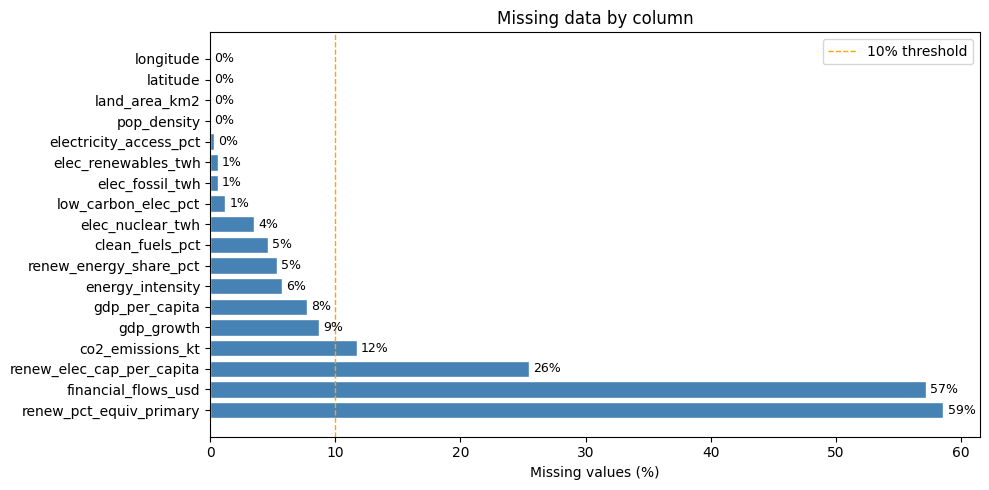

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing.index, missing['missing_pct'], color='steelblue', edgecolor='white')
ax.axvline(10, color='orange', linestyle='--', linewidth=1, label='10% threshold')
ax.set_xlabel('Missing values (%)')
ax.set_title('Missing data by column')
ax.legend()
ax.bar_label(bars, labels=[f"{v:.0f}%" for v in missing['missing_pct']], padding=3, fontsize=9)
plt.tight_layout()
plt.show()

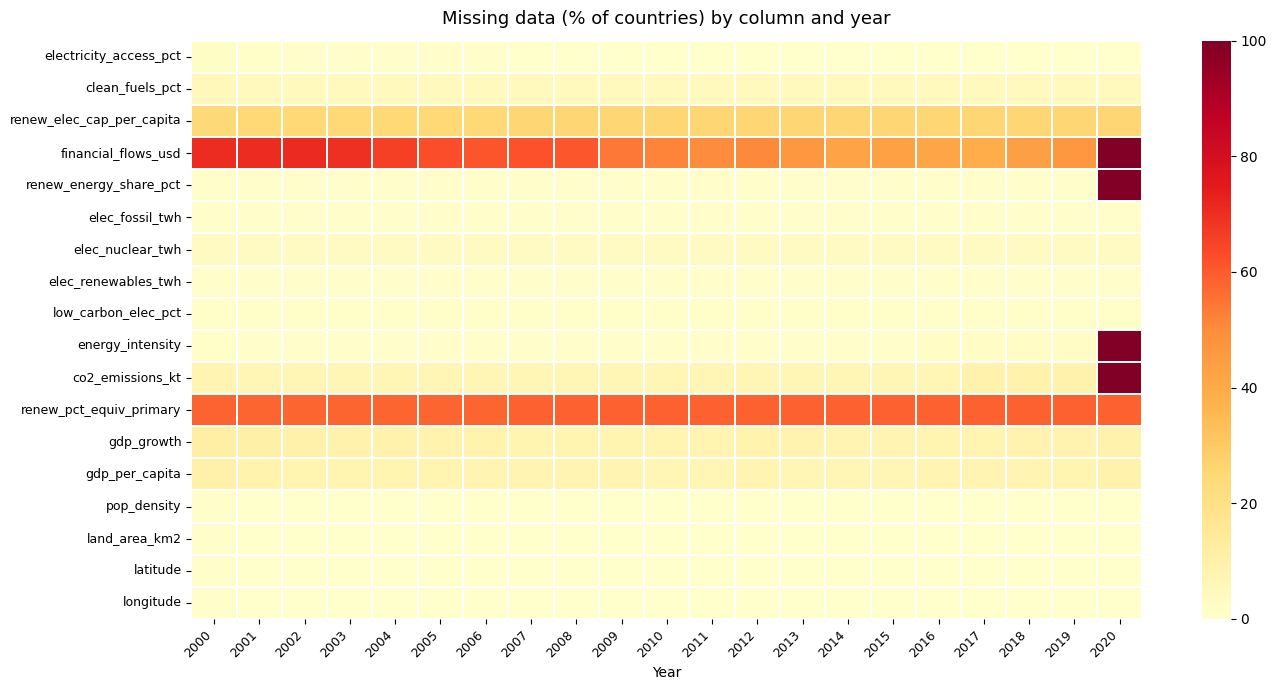

In [9]:
# Only include columns that have *any* missing values
cols_with_missing = [c for c in df.columns if df[c].isnull().any()]

heatmap_data = (
    df.groupby('year')[cols_with_missing]
      .apply(lambda g: g.isnull().mean() * 100)
      .T  # columns = years, rows = column names
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    annot=False,
    vmin=0, vmax=100,
)
ax.set_title('Missing data (% of countries) by column and year', fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

**Key observations from the bar chart and heatmap:**

---

**The 2020 column is almost entirely absent for several key variables.**

The heatmap reveals a sharp discontinuity in the final year: `co2_emissions_kt` is 100% missing in 2020, and `renew_energy_share_pct`, `energy_intensity`, and `financial_flows_usd` each reach ~99% missing. According to the dataset creator, this is simply because the 2020 records had not yet been collected at the time the dataset was assembled. As a result, **2020 will be excluded from any trend analysis using these columns**. Note that `renew_energy_share_pct` additionally has Albania missing across all 20 pre-2020 years, and `energy_intensity` has New Caledonia missing across all 20 pre-2020 years (plus Eritrea, South Sudan, and Yemen for 4 years each); these pre-2020 gaps are attributable to IEA reporting coverage rather than the 2020 collection cutoff.

---

**Structurally sparse columns — stable gap across all years, no improvement over time.**

- `renew_pct_equiv_primary` (~58–59% missing in every year): An IEA-specific metric that is only reported by countries submitting full energy balance data. The heatmap shows a perfectly flat band of consistent missingness — this is not a data collection gap that improved over time, but a structural feature of which countries participate in this particular reporting framework.
- `renew_elec_cap_per_capita` (~25% missing in every year, 2000–2020): Also flat in the heatmap with no improvement. The same set of ~44 countries never report this figure throughout the entire period. Imputing 20 years of values for these countries would be inappropriate.

---

**Definitionally missing — absence is meaningful, not a data problem.**

- `financial_flows_usd` (39–71% missing across years, then 99% in 2020): This column records climate finance flows *received* by developing countries. It is `NaN` for all high-income countries by design — they are donors, not recipients. The moderate improvement from ~70% missing in 2000 to ~39% in 2017 reflects more developing-country coverage over time, not improved data quality for rich nations.
- `elec_nuclear_twh` (~3.5% missing, flat across all years): The heatmap shows a perfectly uniform band — the same ~6 countries are consistently missing. Cross-checking confirms none of these countries ever record positive nuclear generation, so `NaN` here means zero output, not unreported data.

---

**Small consistent gaps — acceptable for most analyses.**

- `clean_fuels_pct` (~4.6–5.2% missing): 8 countries are missing this column across all 21 years: Aruba, Bermuda, Bulgaria, Cayman Islands, Lebanon, Libya, New Caledonia, and Puerto Rico. French Guiana adds 1 row (year 2000 only), accounting for the fractionally higher 2000 figure. The gap is stable, small, and tied to IEA cooking-fuel reporting coverage.
- `gdp_per_capita` and `gdp_growth` (7–10% missing): 22 countries have at least some missing GDP data. Of these, 12 are missing the full 21 years (e.g., Bahamas, Congo, Czechia, Egypt, Saint Kitts and Nevis, Slovakia, Yemen). The remaining 10 have partial gaps — South Sudan (missing 5 of its 8 available years), Somalia (13/21), and Nauru (10/21) being the most notable. GDP will not be imputed; the gaps are tied to real-world reporting constraints.
- `co2_emissions_kt` (~7% missing for 2000–2016, rising to ~9% in 2017–2019, then 100% in 2020): The pre-2020 gaps are concentrated in small territories below national reporting thresholds.

---

**Near-complete columns — no action needed.**

- `electricity_access_pct` (10 NaN): IEA electricity access tracking was incomplete in the early 2000s for a handful of territories: French Guiana (2000), Guinea-Bissau (2000–2001), and Liberia (2000–2006). Tracking reaches 100% from 2007 onwards.
- `elec_fossil_twh` and `elec_renewables_twh`: A flat 0.6% missing throughout — only Tuvalu is missing these values across all 21 years. Tuvalu is a micro-state whose electricity generation falls below the TWh reporting threshold; filled with 0, consistent with how the comparable territory Bermuda is stored in the raw data (genuine zeros, not NaN).
- `pop_density`, `land_area_km2`, `latitude`, `longitude`: 0.6% missing only in year 2000, corresponding to a single French Guiana row. Static geographic values imputed from reference data. Note: the raw CSV stores `pop_density` as a string with comma thousands-separators for high-density countries (e.g. `"1,265"`); commas are stripped before type conversion in §1.7, so no additional NaN are introduced.
- `low_carbon_elec_pct`: 42 NaN values remain, all belonging to Bermuda (21 rows) and Tuvalu (21 rows). Both have a recorded total electricity of zero, making the percentage mathematically undefined. These are left as NaN intentionally.

### 1.6 Handle Missing Values

We apply the strategy identified above to each column group.

In [10]:
# elec_nuclear_twh: NaN means zero nuclear generation.
# Verified: no country with NaN here ever records positive nuclear output.
nuke_nan_countries = df.loc[df['elec_nuclear_twh'].isnull(), 'country'].unique()
nuke_nonzero_countries = df.loc[df['elec_nuclear_twh'] > 0, 'country'].unique()
overlap = set(nuke_nan_countries) & set(nuke_nonzero_countries)
assert len(overlap) == 0, f"Unexpected overlap: {overlap}"

df['elec_nuclear_twh'] = df['elec_nuclear_twh'].fillna(0)

# elec_fossil_twh / elec_renewables_twh: NaN only for Tuvalu (all 21 years).
# Tuvalu is a micro-state whose electricity generation is below the TWh reporting
# threshold of this dataset. Filling with 0 is consistent with how Bermuda
# (a comparable micro-territory) is stored in the raw data.
df['elec_fossil_twh']     = df['elec_fossil_twh'].fillna(0)
df['elec_renewables_twh'] = df['elec_renewables_twh'].fillna(0)

print('NaN remaining after fill:',
      df[['elec_nuclear_twh','elec_fossil_twh','elec_renewables_twh']].isnull().sum().tolist())

NaN remaining after fill: [0, 0, 0]


**French Guiana — imputed geographic values (single row, year 2000):**

| Field | Value | Source |
|---|---|---|
| `pop_density` | 1.9 P/km² | [indexmundi.com](https://www.indexmundi.com/g/g.aspx?v=21000&c=fg&l=en) |
| `land_area_km2` | 83,534 km² | [latitude.to](https://latitude.to/map/gf/french-guiana) |
| `latitude` | 3.93° | [latitude.to](https://latitude.to/map/gf/french-guiana) |
| `longitude` | −53.09° | [latitude.to](https://latitude.to/map/gf/french-guiana) |

In [11]:
fg_mask = df['country'] == 'French Guiana'
df.loc[fg_mask, 'pop_density']   = 1.9
df.loc[fg_mask, 'land_area_km2'] = 83_534
df.loc[fg_mask, 'latitude']      = 3.93
df.loc[fg_mask, 'longitude']     = -53.09

print('French Guiana geo cols filled:')
print(df.loc[fg_mask, ['country','year','pop_density','land_area_km2','latitude','longitude']])

French Guiana geo cols filled:
            country  year  pop_density  land_area_km2  latitude  longitude
1218  French Guiana  2000         1.90       83534.00      3.93     -53.09


In [12]:
# Investigate the 42 remaining NaN in low_carbon_elec_pct
nan_rows = df[df['low_carbon_elec_pct'].isnull()]

print(f'Total NaN: {len(nan_rows)}')
print(f'Countries affected: {sorted(nan_rows["country"].unique())}')
print()

# Show why: check their electricity generation totals
check = (
    nan_rows
    .groupby('country')[['elec_fossil_twh','elec_nuclear_twh','elec_renewables_twh']]
    .agg(['min','max'])
)
print('Electricity TWh range for affected countries:')
print(check)
print()
print('Conclusion: total electricity is 0 in all cases, therefore, percentage is undefined (0 ÷ 0)')

Total NaN: 42
Countries affected: ['Bermuda', 'Tuvalu']

Electricity TWh range for affected countries:
        elec_fossil_twh      elec_nuclear_twh      elec_renewables_twh     
                    min  max              min  max                 min  max
country                                                                    
Bermuda            0.00 0.00             0.00 0.00                0.00 0.00
Tuvalu             0.00 0.00             0.00 0.00                0.00 0.00

Conclusion: total electricity is 0 in all cases, therefore, percentage is undefined (0 ÷ 0)


**Decision: retain as NaN, do not fill with 0.**

Both Bermuda and Tuvalu have total electricity recorded as zero across all 21 years, so `low_carbon_elec_pct` cannot be computed. Filling with `0` would incorrectly imply these territories produce zero low-carbon electricity — which is factually wrong for Tuvalu, which operates solar installations. In practice, both are micro-territories whose electricity output falls below the TWh reporting threshold of this dataset; they will simply be excluded from any chart involving this column, which has no meaningful impact on analysis across 176 countries.

### 1.7 Check for Duplicates

In [13]:
dupes = df.duplicated(subset=['country','year'])
print(f'Duplicate (country, year) pairs: {dupes.sum()}')

# Confirm every country has at most 21 rows (2000-2020)
counts = df.groupby('country').size()
print(f'Min rows per country: {counts.min()}  Max: {counts.max()}')
print('Countries with fewer than 21 years:')
print(counts[counts < 21].sort_values())

Duplicate (country, year) pairs: 0
Min rows per country: 1  Max: 21
Countries with fewer than 21 years:
country
French Guiana     1
South Sudan       8
Montenegro       14
Serbia           14
dtype: int64


### 1.8 Add Derived Columns

A few computed columns will be useful during exploration.

In [14]:
# Total electricity generated (TWh)
df['elec_total_twh'] = df['elec_fossil_twh'] + df['elec_nuclear_twh'] + df['elec_renewables_twh']

# Renewable share of electricity generation (excluding nuclear)
df['renew_elec_share_pct'] = np.where(
    df['elec_total_twh'] > 0,
    df['elec_renewables_twh'] / df['elec_total_twh'] * 100,
    np.nan
)

# CO₂ emissions in million tonnes (easier to read)
df['co2_emissions_mt'] = df['co2_emissions_kt'] / 1_000

print('New columns added:', ['elec_total_twh', 'renew_elec_share_pct', 'co2_emissions_mt'])

New columns added: ['elec_total_twh', 'renew_elec_share_pct', 'co2_emissions_mt']


### 1.9 Summary of the Cleaned Dataset

In [15]:
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Countries: {df["country"].nunique()}')
print(f'Year range: {df["year"].min()} – {df["year"].max()}')
print()
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
print('Remaining NaN per column:')
print(remaining.to_string())

Shape: 3,649 rows × 24 columns
Countries: 176
Year range: 2000 – 2020

Remaining NaN per column:
electricity_access_pct         10
clean_fuels_pct               169
renew_elec_cap_per_capita     931
financial_flows_usd          2089
renew_energy_share_pct        194
low_carbon_elec_pct            42
energy_intensity              207
co2_emissions_kt              428
renew_pct_equiv_primary      2137
gdp_growth                    317
gdp_per_capita                282
renew_elec_share_pct           42
co2_emissions_mt              428


In [16]:
df.describe()

,year,electricity_access_pct,clean_fuels_pct,renew_elec_cap_per_capita,financial_flows_usd,renew_energy_share_pct,elec_fossil_twh,elec_nuclear_twh,elec_renewables_twh,low_carbon_elec_pct,primary_energy_per_capita,energy_intensity,co2_emissions_kt,renew_pct_equiv_primary,gdp_growth,gdp_per_capita,pop_density,land_area_km2,latitude,longitude,elec_total_twh,renew_elec_share_pct,co2_emissions_mt
count,3649.00,3639.00,3480.00,2718.00,1560.00,3455.00,3649.00,3649.00,3649.00,3607.00,3649.00,3442.00,3221.00,1512.00,3332.00,3367.00,3649.00,3649.00,3649.00,3649.00,3649.00,3607.00,3221.00
mean,2010.04,78.93,63.26,113.14,94224000.00,32.64,69.96,12.99,23.83,36.80,25743.98,5.31,159866.46,11.99,3.44,13283.77,223.51,633062.85,18.24,14.80,106.78,32.59,159.87
std,6.05,30.28,39.04,244.17,298154406.59,29.89,347.09,71.78,104.15,34.31,34773.22,3.53,773661.06,14.99,5.69,19709.87,683.38,1585328.00,24.16,66.35,486.88,33.30,773.66
min,2000.00,1.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.11,10.00,0.00,-62.08,111.93,1.90,21.00,-40.90,-175.20,0.00,0.00,0.01
25%,2005.00,59.80,23.18,3.54,260000.00,6.51,0.28,0.00,0.04,2.88,3116.74,3.17,2020.00,2.14,1.38,1337.81,34.00,25713.00,3.20,-11.78,0.89,2.29,2.02
50%,2010.00,98.36,83.15,32.91,5665000.00,23.30,2.94,0.00,1.42,27.87,13120.57,4.30,10500.00,6.29,3.56,4578.63,87.00,117600.00,17.19,19.15,8.68,18.57,10.50
75%,2015.00,100.00,100.00,112.21,55347500.00,55.25,26.52,0.00,9.56,64.40,33892.78,6.03,60580.00,16.84,5.83,15768.62,219.00,513120.00,38.97,46.20,47.74,58.53,60.58
max,2020.00,100.00,100.00,3060.19,5202310000.00,96.04,5184.13,809.41,2184.94,100.00,262585.70,32.57,10707219.73,86.84,123.14,123514.20,8358.00,9984670.00,64.96,178.07,7735.27,100.00,10707.22


**Remaining NaN after cleaning — complete accounting**

All gaps below are retained intentionally. No further imputation is applied.

| Column | NaN | Classification | Reason |
|--------|----:|---|---|
| `renew_pct_equiv_primary` | 2,137 | Structural | IEA metric; only countries submitting full energy-balance data report it. Flat ~59% all 21 years. |
| `financial_flows_usd` | 2,089 | Definitional | Records inflows to developing countries; `NaN` for all high-income donor nations by design. |
| `renew_elec_cap_per_capita` | 931 | Structural | Same 44 countries missing all 21 years; no time-trend to impute. |
| `energy_intensity` | 207 | Mixed | 174 from 2020 (not yet collected); 33 from New Caledonia (all 20 pre-2020 years), Eritrea, South Sudan, Yemen, and French Guiana. |
| `co2_emissions_kt` | 428 | Mixed | 174 from 2020; 253 pre-2020 for countries below national reporting thresholds. |
| `co2_emissions_mt` | 428 | Derived | Derived from `co2_emissions_kt`; inherits the same NaN. |
| `gdp_growth` | 317 | Reporting gap | World Bank data absent for the same countries as `gdp_per_capita`, plus additional partial gaps. |
| `gdp_per_capita` | 282 | Reporting gap | 12 countries with no World Bank records at all; 10 with partial gaps. |
| `clean_fuels_pct` | 169 | Structural | 8 countries missing all 21 years: Aruba, Bermuda, Bulgaria, Cayman Islands, Lebanon, Libya, New Caledonia, Puerto Rico; plus French Guiana (1 row). |
| `renew_energy_share_pct` | 194 | Mixed | 174 from 2020; 20 from Albania missing all 20 pre-2020 years. |
| `low_carbon_elec_pct` | 42 | Undefined | Bermuda and Tuvalu: `elec_total_twh = 0`; percentage is mathematically undefined (0 ÷ 0). |
| `renew_elec_share_pct` | 42 | Derived | Derived column; inherits NaN from same Bermuda + Tuvalu rows. |
| `electricity_access_pct` | 10 | Early tracking | French Guiana (2000), Guinea-Bissau (2000–2001), Liberia (2000–2006); IEA tracking reaches 100% from 2007. |


### 1.10 Save the Refined Dataset

In [17]:
output_path = 'global-data-on-sustainable-energy-cleaned.csv'
df.to_csv(output_path, index=False)
print(f'Saved: {output_path}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Saved: global-data-on-sustainable-energy-cleaned.csv
Shape: 3,649 rows x 24 columns
